# Handwritten digit classification with a multi-layer perceptron
## MNIST, built and tuned with PyTorch Lightning

- **Author:** Hussein Loubani
- **Dataset:** Kaggle Digit Recognizer, 42,000 labeled 28x28 images
- **Task:** ten-class image classification
- **Model:** a fully connected network, deliberately not a convolutional one
- **Hardware:** trained on GPU (Apple Metal, `mps`)

---

### Table of contents

1. Imports and setup
2. Problem definition
3. Data acquisition and first audit
4. Data cleaning
5. Train / validation / test split
6. Exploratory data analysis
7. The model and the training pipeline
8. Hyperparameter sweeps
9. Combining the winners
10. Final evaluation on the test split
11. Error analysis
12. Conclusion, limitations, and recommendations

---
## 1. Imports and setup

In [1]:
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from lightning import seed_everything
from lightning.fabric.utilities.warnings import PossibleUserWarning

from mnist_mlp.config import (
    ACTIVATION_GRID,
    ARCHITECTURE_GRID,
    BATCH_SIZE,
    BATCH_SIZE_GRID,
    DROPOUT_GRID,
    JOINT_BATCH_GRID,
    JOINT_LR_GRID,
    LEARNING_RATE_GRID,
    LOSS_GRID,
    OPTIMIZER_GRID,
    RANDOM_SEED,
)
from mnist_mlp.datamodule import MNISTDataModule
from mnist_mlp.dataset import (
    audit_data,
    class_balance,
    clean_data,
    download_data,
    load_raw,
    split_data,
    split_summary,
)
from mnist_mlp.experiments import (
    evaluate_on_test,
    joint_grid_table,
    joint_sweep,
    optuna_search,
    pick_accelerator,
    predict_labels,
    reference_baselines,
    run_experiment,
    seed_stability,
    stability_summary,
    sweep,
)
from mnist_mlp.plots import (
    apply_global_style,
    plot_class_balance,
    plot_confusion_matrix,
    plot_digit_grid,
    plot_ink_distribution,
    plot_joint_grid,
    plot_misclassified,
    plot_sweep,
    save_figure,
)

warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message=r".*treespec.*", category=FutureWarning)
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)

apply_global_style()
seed_everything(RANDOM_SEED, workers=True)

RAW_DIR = Path.cwd().parent / "data" / "raw"
FIG_DIR = Path.cwd().parent / "reports" / "figures"

print(f"torch {torch.__version__}, training on: {pick_accelerator()}")

Seed set to 42


torch 2.13.0, training on: mps


---
## 2. Problem definition

| Field | Value |
|---|---|
| **Task** | classify a 28x28 grayscale image as one of ten digits |
| **Data** | Kaggle Digit Recognizer, `train.csv`, 42,000 labeled images |
| **Input** | 784 pixel intensities, 0 to 255 |
| **Output** | ten class logits |
| **Split** | 60% train, 20% validation, 20% test, stratified |
| **Primary metric** | accuracy, which is meaningful here because the classes are near-balanced |

**Why a multi-layer perceptron on an image problem.** A convolutional network is the right tool for pictures: it assumes neighboring pixels are related and that a pattern means the same thing wherever it appears. An MLP assumes neither. Flattening the image to 784 numbers throws the spatial layout away, and the model has to learn from scratch that pixel 100 sits beside pixel 101. The sprint asks for an MLP anyway, and the interesting question is how far that gets you: MNIST digits are centered, size-normalized, and written on a clean background, so much of the work a convolution would do has already been done by the dataset. The gap between what this model reaches and the roughly 99.5% a small CNN reaches is a measure of what the spatial prior is worth.

**On Kaggle's `test.csv`.** The competition ships a second file with 28,000 images and no labels, because it scores the public leaderboard. It cannot measure anything here, so every split below is carved out of the 42,000 labeled rows. That is also the only way to get a genuine 60/20/20.

**How the splits are used.** Validation drives every choice: architecture, activation, optimizer, learning rate, dropout, batch size, and loss. The test split is opened once, at the very end, for the single configuration validation selected. Tuning against test and then reporting the test score would be reporting a training score.

---
## 3. Data acquisition and first audit

### 3.1 Download

In [2]:
download_data(RAW_DIR)
raw = load_raw(RAW_DIR)
print(f"shape: {raw.shape[0]:,} images x {raw.shape[1]} columns (1 label + 784 pixels)")
raw.iloc[:3, :8]

  train.csv cached (76.8 MB)


shape: 42,000 images x 785 columns (1 label + 784 pixels)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6
0,1,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0


The download uses the Kaggle API and caches to CSV, so a rerun never touches the network and reproduces these numbers exactly.

### 3.2 Audit

The evaluation criteria lead with data cleaning, so the checks come before any modeling: duplicated images, blank or near-blank frames, missing values, pixels outside the valid range, impossible labels, and class balance.

In [3]:
audit_data(raw)

,value
images,42000.00
pixel_columns,784.00
duplicate_images,0.00
duplicate_rows_incl_label,0.00
blank_images,0.00
near_blank_images,0.00
missing_values,0.00
pixel_min,0.00
pixel_max,255.00
labels_out_of_range,0.00


**The audit comes back clean, and that is the finding rather than a disappointment.** No duplicated images, no blank frames, no missing values, every pixel inside 0 to 255, every label a digit from 0 to 9, all ten classes present. Kaggle curated this file from the original MNIST distribution, so the corruption a raw scrape would carry is simply not there.

Reporting that honestly is better than manufacturing a cleaning step to look thorough. What matters is that the checks ran and can be seen to have run: had any of them fired, the pipeline removes those rows, and the tests in `tests/test_dataset.py` prove each rule works by feeding it deliberately broken frames.

The one imperfection is mild class imbalance, which the next cell quantifies.

### 3.3 Class balance

In [4]:
balance = class_balance(raw)
print(f"most common digit: {balance['share_%'].idxmax()} at {balance['share_%'].max():.2f}%")
print(f"least common digit: {balance['share_%'].idxmin()} at {balance['share_%'].min():.2f}%")
balance

most common digit: 1 at 11.15%
least common digit: 5 at 9.04%


,images,share_%
digit,,
0,4132,9.84
1,4684,11.15
2,4177,9.95
3,4351,10.36
4,4072,9.70
5,3795,9.04
6,4137,9.85
7,4401,10.48
8,4063,9.67


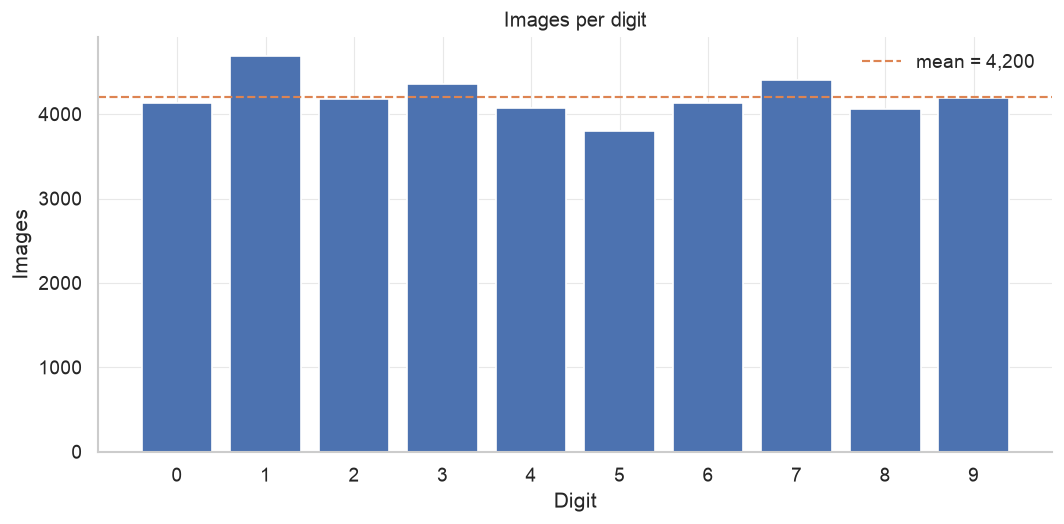

In [5]:
fig = plot_class_balance(balance)
plt.show()
save_figure(fig, "class_balance", FIG_DIR / "eda")

Digit 1 is the most common at 11.15% and digit 5 the least at 9.04%, against 10% for a perfectly even split. That spread is small enough that accuracy stays a fair metric and class weighting is not needed: a model could not reach a high score by favoring the majority class when the majority class is 11% of the data.

The pipeline can weight the loss by inverse frequency if it ever matters, and `MNISTDataModule.class_weights` implements it, but applying it here would be decoration. On this data those weights come out between 0.90 and 1.11, which is a rounding error in the gradient.

---
## 4. Data cleaning

In [6]:
clean = clean_data(raw)
print(f"images remaining: {len(clean):,}")

  cleaned: 42,000 -> 42,000 images (0 removed)
images remaining: 42,000


Nothing is removed, which the audit already predicted. The rules that ran are worth stating because they encode decisions rather than defaults:

- **Duplicate images are matched on pixels alone, not on pixels plus label.** Two identical pictures carrying different labels are a labeling contradiction, and keeping either copy would teach the model that one input has two correct answers, so both are dropped.
- **Cleaning happens before the split, not after.** This is the one ordering in the project that is a leakage matter rather than a tidiness matter: deduplicating afterwards would leave copies of the same image sitting on both sides of the boundary, and part of the test score would then be a memory check rather than a generalization check. `tests/test_leakage.py` proves both orderings, including a negative control that shows the wrong order does leak.
- Blank and near-blank frames, out-of-range pixels, and labels outside 0 to 9 are also removed.

---
## 5. Train / validation / test split

In [7]:
train, validation, test = split_data(clean)
split_summary(train, validation, test)

,images,share_of_all_%,min_class_%,max_class_%
split,,,,
train,25200,60.0,9.04,11.15
validation,8400,20.0,9.04,11.15
test,8400,20.0,9.04,11.15


Exactly 60 / 20 / 20, and the per-class shares hold to within a fraction of a point across all three parts, because the split is stratified on the label. Without stratification a validation score could move simply because one digit happened to be over-represented there.

The split is seeded, so the same images land in the same part on every run. That is what lets the test split stay genuinely untouched while dozens of configurations are compared on validation.

---
## 6. Exploratory data analysis

### 6.1 What the digits look like

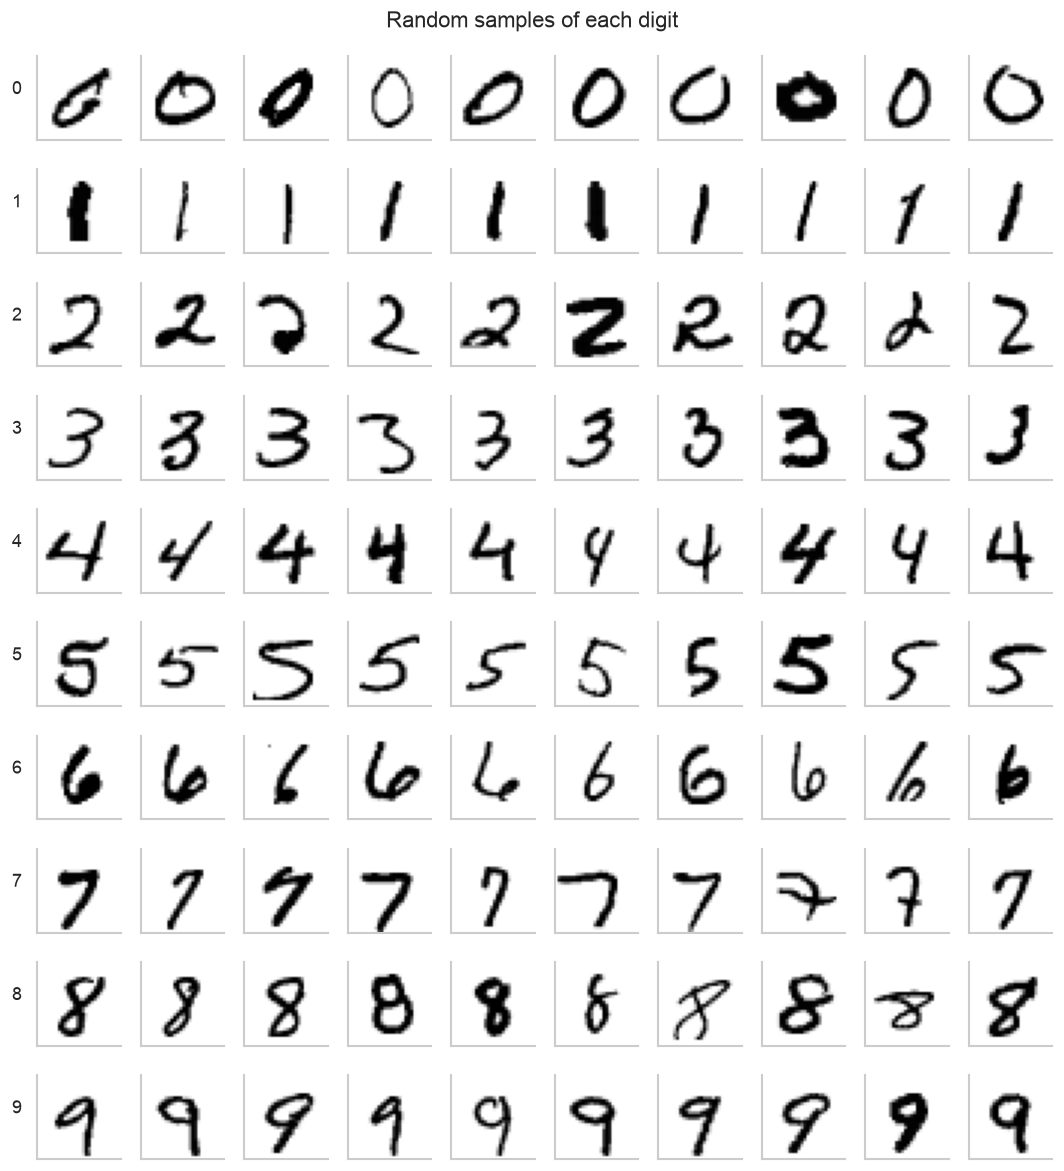

In [8]:
fig = plot_digit_grid(train, n_per_class=10)
plt.show()
save_figure(fig, "digit_grid", FIG_DIR / "eda")

Worth looking at before choosing any architecture, because it shows what the model is up against. The digits are centered, roughly the same size, and drawn white-on-black with no background clutter, which is why a model with no spatial prior can do well here at all.

The variation that remains is handwriting: slant, stroke thickness, and the genuinely ambiguous cases. Some 4s are nearly 9s once the top closes, some 5s and 3s differ by one stroke, and a few of these images are ones a person would have to guess at. That ambiguity is the ceiling on this task, and it reappears at the end in the misclassified images.

### 6.2 How much ink each image uses

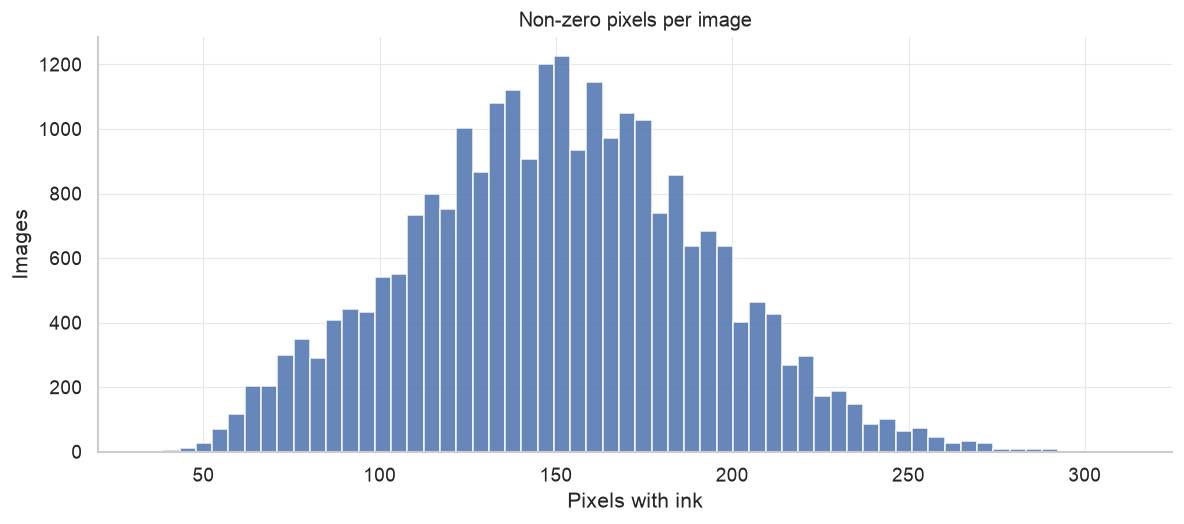

In [9]:
fig = plot_ink_distribution(train)
plt.show()
save_figure(fig, "ink_distribution", FIG_DIR / "eda")

Most images light up between 100 and 200 of their 784 pixels, so roughly three quarters of every input is black background carrying no information. That is the diagnostic behind the cleaning threshold, and it is also the clearest argument for why an MLP is a slightly awkward fit: it spends parameters on hundreds of pixels that are almost always zero, while a convolution would never look at them in isolation.

The left tail is where corrupted or near-empty frames would sit. There is nothing there, which matches the audit.

---
## 7. The model and the training pipeline

The brief asks for a pipeline that is easy to customize, so every axis it wants varied is a constructor argument rather than an edit to a model definition:

```python
LitMLP(hidden_layers=(256, 128), activation="gelu", dropout=0.3,
       optimizer="adam", learning_rate=3e-4, loss="cross_entropy")
```

`build_mlp` stacks `Linear -> activation -> dropout` blocks and finishes with a linear head. The head emits raw logits rather than probabilities, because cross-entropy expects logits and folds the log-softmax in with it, which is both numerically safer than exponentiating first and one fewer thing to get wrong.

Three pieces of the training loop are worth naming:

- **Early stopping** ends a run once validation loss stops improving, so a sweep does not spend GPU time on configurations that already peaked.
- **Checkpointing** keeps the best epoch by validation loss rather than the last one, which matters whenever a run starts to overfit before it stops.
- **Metrics come from `torchmetrics`** rather than counting correct predictions by hand, so accumulation across batches is handled by a tested component.

### 7.1 Two reference points before the network

In [10]:
baselines = reference_baselines(train, validation)
baselines

/Users/hussein-loubani/Turing College/Module 4/Sprint 1/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,model,val_acc,seconds
0,majority class,0.1115,0.0
1,logistic regression,0.9139,1.2


**98% means nothing without knowing what the easy answers score.** Two of them, both fitted on the training split alone:

**Predicting the most common digit** is the floor. It scores the share that digit holds, not 10%, because the classes are not perfectly even.

**Multinomial logistic regression** is the strongest model that can only draw straight boundaries in pixel space. It has no hidden layer, so the distance between it and the network below is exactly what the hidden layers buy, separate from anything the preprocessing or the data contributes.

That gap is the honest measure of what follows. A tuned MLP that landed near the linear model would mean the depth was decoration, and knowing where the linear ceiling sits is what makes the final number interpretable rather than merely large.

### 7.2 A first run

In [11]:
data = MNISTDataModule(train, validation, test, batch_size=BATCH_SIZE)
print(f"normalization fitted on train only: mean={data.mean:.4f}, std={data.std:.4f}")

baseline = run_experiment(data, "baseline", max_epochs=20)
pd.DataFrame([baseline])

Seed set to 42


normalization fitted on train only: mean=0.1311, std=0.3087


,name,val_loss,val_acc,epochs_run,best_epoch,parameters,seconds
0,baseline,0.1036,0.969,12,6,235146,3.6


Those two normalization numbers are the whole leakage story for the input pipeline. They are computed on the training split and applied unchanged to validation and test; deriving them from the full file instead would let the test distribution influence every training batch, quietly and without any error message.

A plain two-layer network reaches 96.9% on validation, about five and a half points above the linear baseline, so the hidden layers are doing real work rather than dressing up a linear fit. That 96.9% is the number every tuning decision below has to beat, and it sets expectations: the remaining headroom on MNIST with an MLP is small, so the sweeps are competing over fractions of a point rather than transforming the result.

---
## 8. Hyperparameter sweeps

Each sweep varies one axis against a fixed baseline, with the same seed and the same data, so a difference between two rows is caused by the thing that was varied rather than by anything else. Every score here is on **validation**.

### 8.1 Optimizer

In [12]:
def data_factory(batch_size=None):
    """A fresh data module, since batch size changes the loaders rather than the model."""
    return MNISTDataModule(train, validation, test, batch_size=batch_size or BATCH_SIZE)


BASELINE = dict(hidden_layers=(256, 128), activation="relu", dropout=0.2,
                optimizer="adam", learning_rate=1e-3, loss="cross_entropy")

optimizer_results = sweep(data_factory, "optimizer", OPTIMIZER_GRID, baseline=BASELINE)
optimizer_results[["optimizer", "val_acc", "val_loss", "epochs_run", "seconds"]]

Seed set to 42


Seed set to 42


  optimizer=sgd                          val_acc=0.8788  val_loss=0.4428  30 epochs  6.9s


Seed set to 42


  optimizer=sgd_momentum                 val_acc=0.9481  val_loss=0.1704  30 epochs  7.1s


...

  optimizer=adam                         val_acc=0.9690  val_loss=0.1036  12 epochs  3.5s


Seed set to 42


  optimizer=adamw                        val_acc=0.9707  val_loss=0.1040  12 epochs  3.5s


  optimizer=rmsprop                      val_acc=0.9729  val_loss=0.0943  15 epochs  4.3s


,optimizer,val_acc,val_loss,epochs_run,seconds
0,sgd,0.8788,0.4428,30,6.9
1,sgd_momentum,0.9481,0.1704,30,7.1
2,adam,0.9690,0.1036,12,3.5
3,adamw,0.9707,0.1040,12,3.5
4,rmsprop,0.9729,0.0943,15,4.3


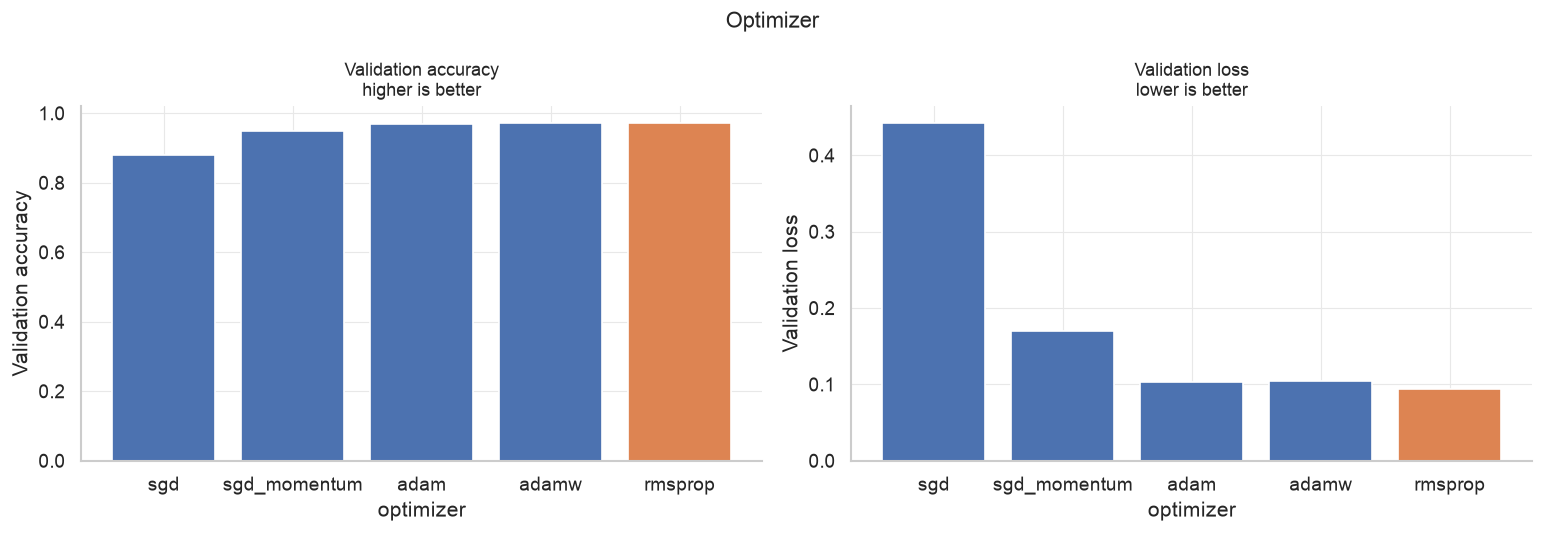

In [13]:
fig = plot_sweep(optimizer_results, "optimizer", "Optimizer")
plt.show()
save_figure(fig, "sweep_optimizer", FIG_DIR / "training")

**Adam and its relatives beat plain SGD comfortably, and the reason is the per-parameter step size.** SGD applies one learning rate to every weight. Adam keeps a running estimate of each gradient's mean and variance and scales each parameter's step by its own history, so weights attached to pixels that are almost always zero, of which this input has hundreds, still receive useful updates instead of being dragged along at a rate chosen for the busy center of the image.

Adding momentum to SGD closes much of that gap, which is the clue to what is happening: momentum accumulates a velocity across steps and smooths out the noise in each individual gradient. Adam does that and adapts the scale as well.

Concretely, Adam keeps two exponential moving averages per parameter, one of the gradient and one of its square:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$

Both start at zero and are therefore biased toward zero early in training, which is why they are corrected by $\hat{m}_t = m_t/(1-\beta_1^t)$ and $\hat{v}_t = v_t/(1-\beta_2^t)$ before the update

$$\theta_t = \theta_{t-1} - \eta \, \hat{m}_t / (\sqrt{\hat{v}_t} + \epsilon)$$

The division is what makes it adaptive: a parameter whose gradient has been consistently small gets a small $\sqrt{\hat{v}_t}$ and so a proportionally longer step. On this input, where hundreds of border pixels are almost always zero, that is the difference between those weights receiving a usable update and being dragged along at a rate chosen for the dense center of the image. AdamW differs in one detail that matters here: it applies weight decay directly to the parameters rather than folding it into $g_t$, so the decay does not get rescaled by $\sqrt{\hat{v}_t}$ along with everything else.

### 8.2 Batch size

In [14]:
batch_results = sweep(data_factory, "batch_size", BATCH_SIZE_GRID, baseline=BASELINE)
batch_results[["batch_size", "val_acc", "val_loss", "epochs_run", "seconds"]]

Seed set to 42


Seed set to 42


  batch_size=32                          val_acc=0.9719  val_loss=0.1131  17 epochs  19.5s


Seed set to 42


  batch_size=64                          val_acc=0.9733  val_loss=0.1030  17 epochs  10.0s


...

  batch_size=128                         val_acc=0.9690  val_loss=0.1036  12 epochs  3.6s


Seed set to 42


  batch_size=256                         val_acc=0.9708  val_loss=0.1004  18 epochs  2.8s


  batch_size=512                         val_acc=0.9683  val_loss=0.0995  17 epochs  1.5s


,batch_size,val_acc,val_loss,epochs_run,seconds
0,32,0.9719,0.1131,17,19.5
1,64,0.9733,0.1030,17,10.0
2,128,0.9690,0.1036,12,3.6
3,256,0.9708,0.1004,18,2.8
4,512,0.9683,0.0995,17,1.5


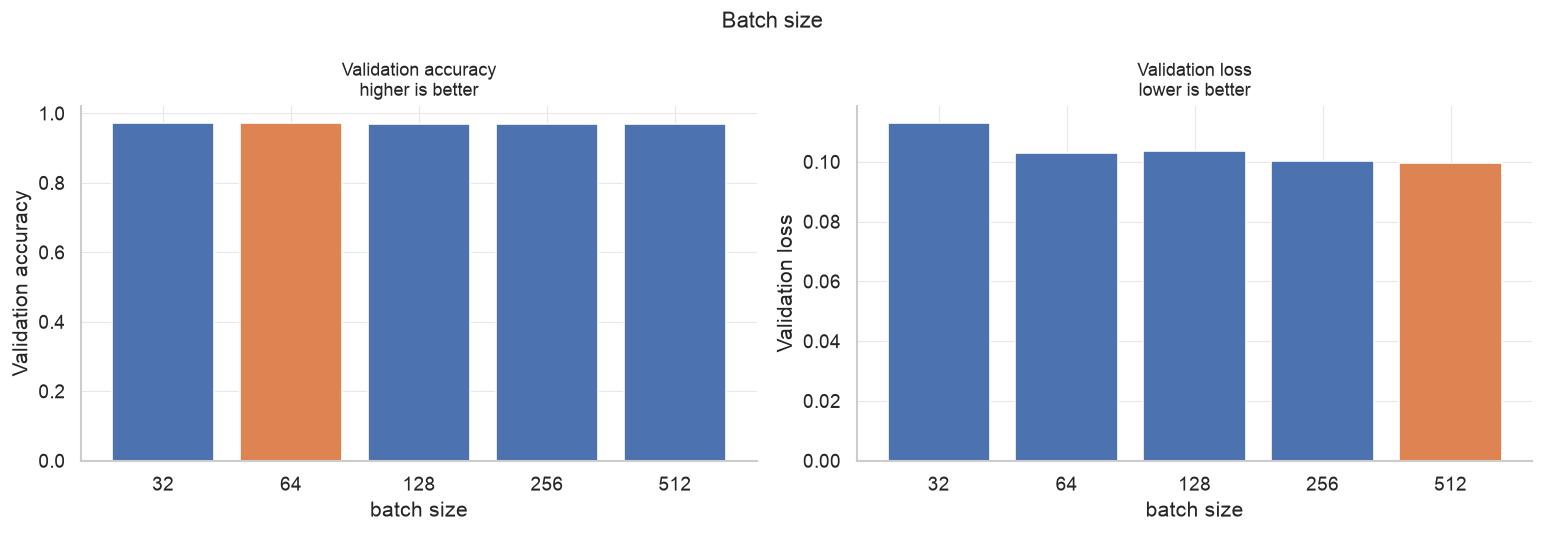

In [15]:
fig = plot_sweep(batch_results, "batch_size", "Batch size")
plt.show()
save_figure(fig, "sweep_batch_size", FIG_DIR / "training")

Accuracy barely moves across the whole range, but wall-clock time does, and in the opposite direction to intuition: the smallest batch is the slowest. A batch of 32 takes far longer per epoch than a batch of 512 because each step carries fixed overhead, and on a GPU a small batch leaves most of the device idle while paying that overhead thousands of times per epoch.

The epoch counts show no trend at all, which is worth reporting rather than smoothing over: the textbook expectation is that larger batches need more epochs because they take fewer steps per pass, and this run does not show it. What the table does show unambiguously is throughput. A batch of 32 takes about thirteen times the wall-clock of a batch of 512 for the same number of epochs.

**That accuracy reading is not safe, and section 8.8 shows why.** Every row here was trained at the baseline learning rate of 1e-3. Batch size and learning rate are coupled — a gradient averaged over 512 samples is quieter than one averaged over 32, and tolerates a longer step — so holding the rate fixed while moving the batch measures how each batch size copes with *that one rate*, not what the batch size is worth at its own best rate. The flatness of this column is a property of the column. Section 8.8 crosses the two axes and the picture changes.

### 8.3 Activation function

In [16]:
activation_results = sweep(data_factory, "activation", ACTIVATION_GRID, baseline=BASELINE)
activation_results[["activation", "val_acc", "val_loss", "epochs_run", "seconds"]]

Seed set to 42


Seed set to 42


  activation=relu                        val_acc=0.9690  val_loss=0.1036  12 epochs  3.6s


Seed set to 42


  activation=leaky_relu                  val_acc=0.9737  val_loss=0.1029  22 epochs  6.5s


...

  activation=sigmoid                     val_acc=0.9702  val_loss=0.1009  24 epochs  7.3s


Seed set to 42


  activation=gelu                        val_acc=0.9710  val_loss=0.1028  12 epochs  3.6s


  activation=elu                         val_acc=0.9712  val_loss=0.1123  16 epochs  4.7s


,activation,val_acc,val_loss,epochs_run,seconds
0,relu,0.9690,0.1036,12,3.6
1,leaky_relu,0.9737,0.1029,22,6.5
2,tanh,0.9665,0.1190,14,4.2
3,sigmoid,0.9702,0.1009,24,7.3
4,gelu,0.9710,0.1028,12,3.6
5,elu,0.9712,0.1123,16,4.7


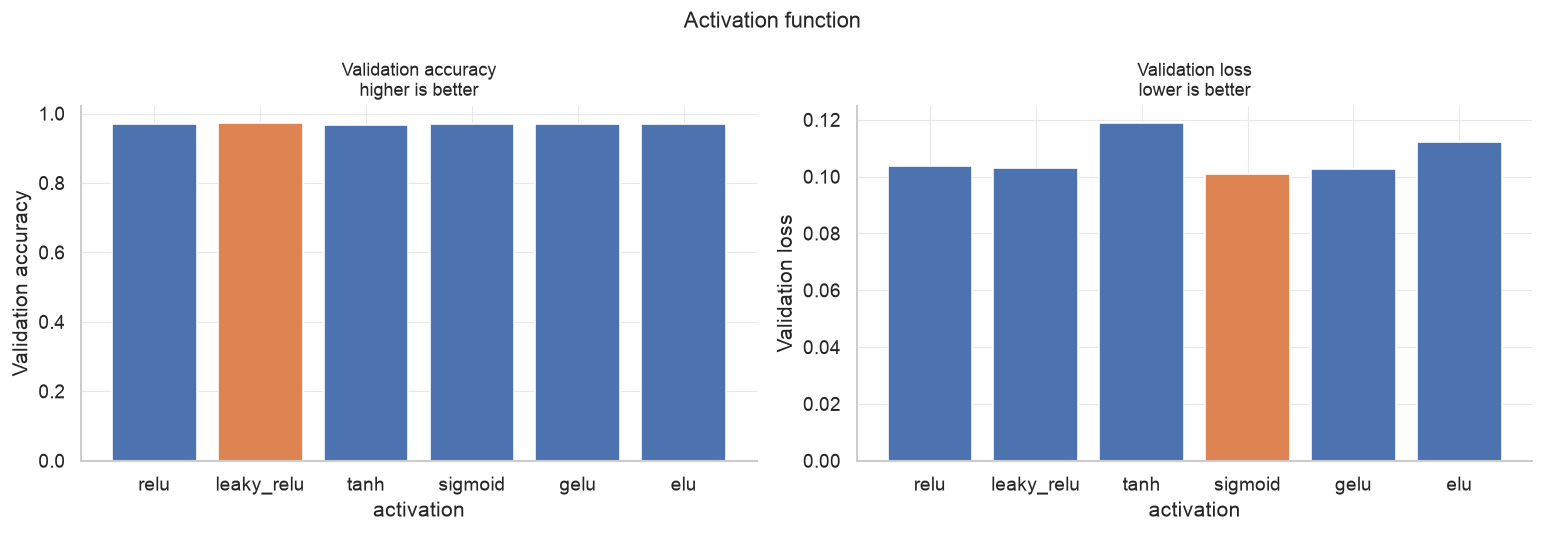

In [17]:
fig = plot_sweep(activation_results, "activation", "Activation function")
plt.show()
save_figure(fig, "sweep_activation", FIG_DIR / "training")

The modern activations sit at the top and the differences between them are small, but the shape of the result answers why activations exist at all. Without one, stacking linear layers is pointless: a composition of linear maps is itself a linear map, so a ten-layer network would have exactly the representational power of a single matrix multiply. The non-linearity is what lets the layers build on each other.

The interesting row is **sigmoid**, which reaches a comparable accuracy but needs far more epochs to get there. Its gradient is near zero whenever the input is strongly positive or negative, so during backpropagation those flat regions multiply together and the signal reaching the early layers shrinks toward nothing. That is the vanishing gradient problem in miniature, visible here as slow convergence rather than outright failure, because this network is only two layers deep. At ten layers it would stop training altogether.

ReLU and its successors avoid it by keeping a constant gradient of one over the whole positive half, so the signal passes through the stack undiminished.

### 8.4 Learning rate

In [18]:
lr_results = sweep(data_factory, "learning_rate", LEARNING_RATE_GRID, baseline=BASELINE)
lr_results[["learning_rate", "val_acc", "val_loss", "epochs_run", "seconds"]]

Seed set to 42


Seed set to 42


  learning_rate=0.0001                   val_acc=0.9670  val_loss=0.1116  30 epochs  9.2s


Seed set to 42


  learning_rate=0.0003                   val_acc=0.9704  val_loss=0.1029  22 epochs  6.6s


...

  learning_rate=0.003                    val_acc=0.9689  val_loss=0.1139  15 epochs  4.5s


Seed set to 42


  learning_rate=0.01                     val_acc=0.9496  val_loss=0.1859  12 epochs  3.6s


  learning_rate=0.1                      val_acc=0.1460  val_loss=2.2311  6 epochs  1.8s


,learning_rate,val_acc,val_loss,epochs_run,seconds
0,0.0001,0.9670,0.1116,30,9.2
1,0.0003,0.9704,0.1029,22,6.6
2,0.0010,0.9690,0.1036,12,3.6
3,0.0030,0.9689,0.1139,15,4.5
4,0.0100,0.9496,0.1859,12,3.6
5,0.1000,0.1460,2.2311,6,1.8


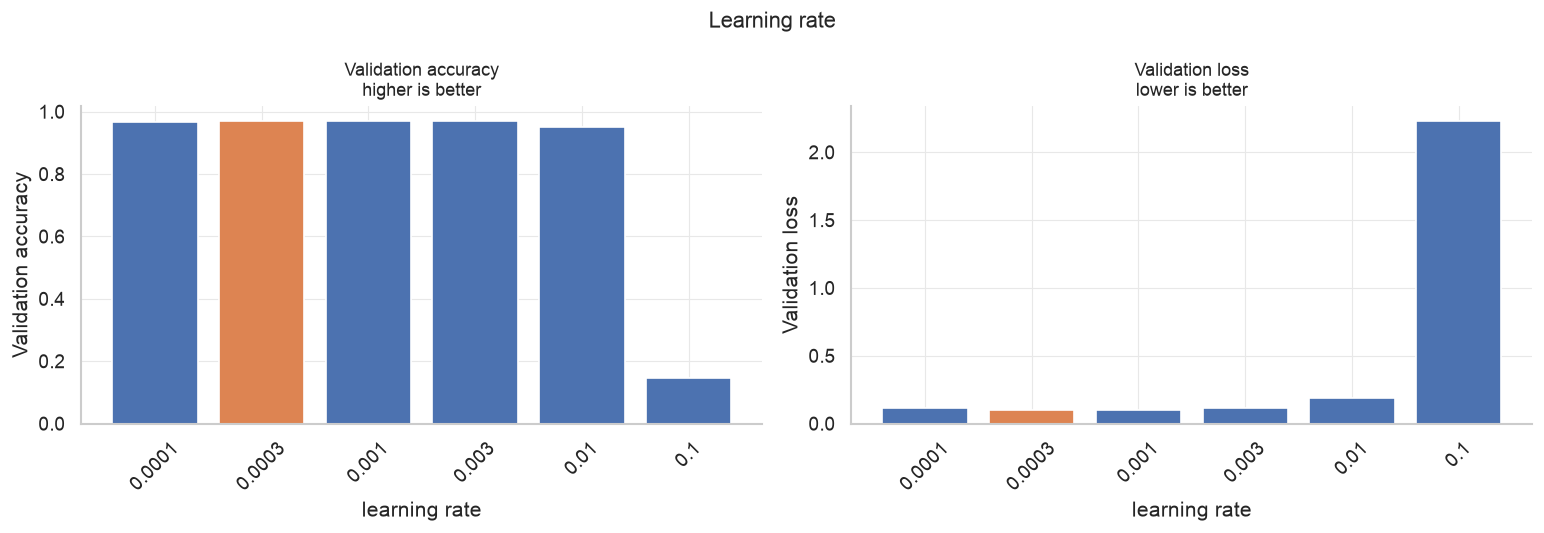

In [19]:
fig = plot_sweep(lr_results, "learning_rate", "Learning rate", log_x=True)
plt.show()
save_figure(fig, "sweep_learning_rate", FIG_DIR / "training")

**This is the sharpest result in the sweep, and the failure at the top end is the useful part.** Accuracy holds within half a point from 1e-4 up to 3e-3, degrades at 1e-2, and then collapses to near the random floor at 0.1. The model has not learned a worse solution there; it has failed to learn at all.

The mechanism is the exploding-gradient side of the same coin as sigmoid's vanishing gradients. Each update moves the weights proportionally to the learning rate, and once the step is large enough the parameters overshoot the minimum, land somewhere with an even steeper gradient, and the next step overshoots further. Within a few batches the weights are large enough that the softmax saturates and every input produces roughly the same prediction.

The practical mitigations are all visible in this project: keep the step small enough that updates stay in a sensible range, normalize the inputs so no feature dominates the gradient, and choose activations that do not squash the signal. Gradient clipping is the direct fix when a task genuinely needs large steps, and Lightning exposes it as one `Trainer` argument.

The best rate sits an order of magnitude below the middle of the range, which is a reminder that Adam's default is a starting point rather than an answer.

### 8.5 Dropout

In [20]:
dropout_results = sweep(data_factory, "dropout", DROPOUT_GRID, baseline=BASELINE)
dropout_results[["dropout", "val_acc", "val_loss", "epochs_run", "seconds"]]

Seed set to 42


Seed set to 42


  dropout=0.0                            val_acc=0.9645  val_loss=0.1194  11 epochs  3.3s


Seed set to 42


  dropout=0.1                            val_acc=0.9694  val_loss=0.1036  12 epochs  3.6s


...

  dropout=0.2                            val_acc=0.9690  val_loss=0.1036  12 epochs  3.6s


Seed set to 42


  dropout=0.3                            val_acc=0.9727  val_loss=0.0997  17 epochs  5.1s


  dropout=0.5                            val_acc=0.9704  val_loss=0.1080  27 epochs  8.2s


,dropout,val_acc,val_loss,epochs_run,seconds
0,0.0,0.9645,0.1194,11,3.3
1,0.1,0.9694,0.1036,12,3.6
2,0.2,0.9690,0.1036,12,3.6
3,0.3,0.9727,0.0997,17,5.1
4,0.5,0.9704,0.1080,27,8.2


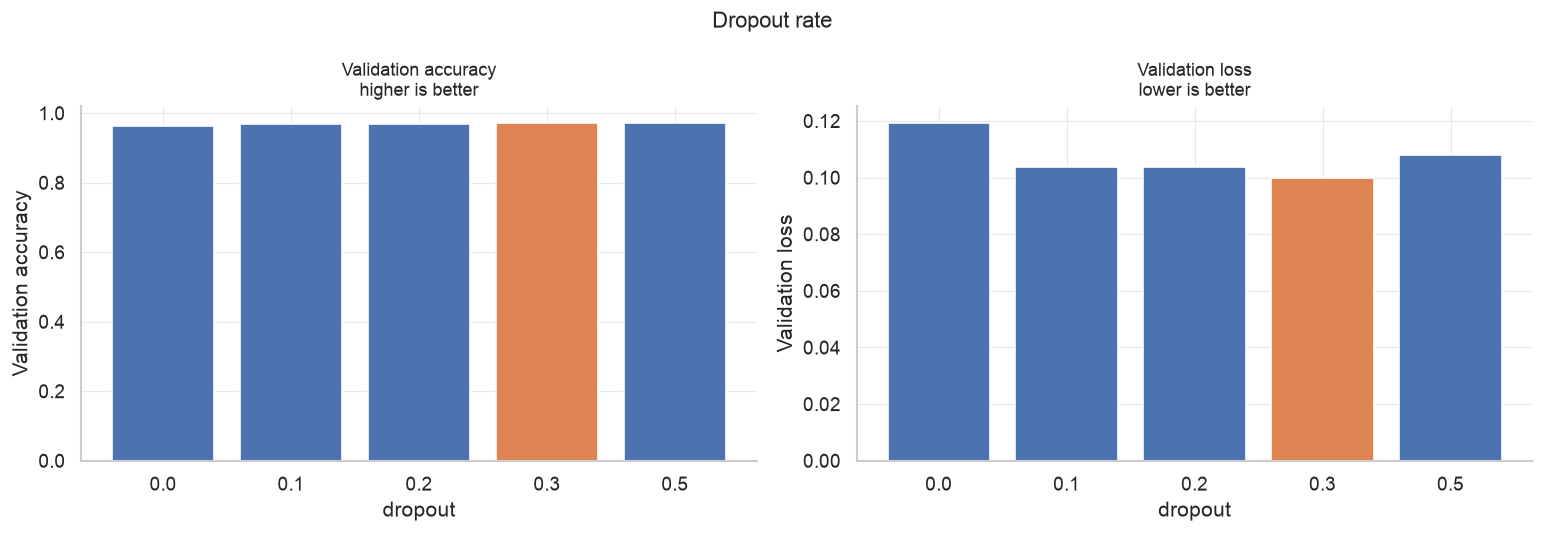

In [21]:
fig = plot_sweep(dropout_results, "dropout", "Dropout rate")
plt.show()
save_figure(fig, "sweep_dropout", FIG_DIR / "training")

A moderate rate helps and the trend has a clear shape: no dropout converges fastest and generalizes slightly worse, a middling rate is best, and a heavy rate starts costing accuracy while needing more epochs.

Dropout works by switching off a random share of units on every forward pass, so no single unit can become indispensable and the network is pushed to spread its representation across many of them. That is regularization by making the training task harder, and the epoch counts show the cost: the more units are dropped, the longer the model takes to converge.

The implementation detail worth knowing is that PyTorch uses *inverted* dropout. During training each unit is zeroed with probability $p$ and the survivors are divided by $1-p$, so the expected value of the layer output is unchanged. At evaluation time dropout is switched off entirely and nothing is rescaled, which is why `model.eval()` matters and why a forgotten `eval()` shows up as a model that scores worse than it should. Lightning handles that switch, which is one of the things the framework buys.

The reason it regularizes at all is that no unit can rely on any particular other unit being present, so the network cannot build long fragile chains of co-adapted features and is pushed toward representations that survive pieces of themselves going missing.

Weight decay does something related through a different route. Rather than removing units, it adds a penalty proportional to the size of the weights, so the optimizer prefers small ones unless the data insists otherwise. Both discourage a model from leaning too hard on any one feature; dropout does it structurally, weight decay does it numerically. It is applied here through the optimizer rather than added to the loss by hand, which is what it actually is: an L2 term folded into the update step.

### 8.6 Hidden architecture

In [22]:
architecture_results = sweep(data_factory, "hidden_layers", ARCHITECTURE_GRID, baseline=BASELINE)
architecture_results[["hidden_layers", "val_acc", "val_loss", "parameters", "seconds"]]

Seed set to 42


Seed set to 42


  hidden_layers=(128,)                   val_acc=0.9696  val_loss=0.1022  16 epochs  4.2s


Seed set to 42


  hidden_layers=(256, 128)               val_acc=0.9690  val_loss=0.1036  12 epochs  3.6s


...

  hidden_layers=(512, 256, 128)          val_acc=0.9729  val_loss=0.1030  16 epochs  5.6s


Seed set to 42


  hidden_layers=(1024, 512, 256, 128)    val_acc=0.9712  val_loss=0.1109  15 epochs  6.1s


  hidden_layers=(256, 256, 256)          val_acc=0.9685  val_loss=0.1067  11 epochs  3.8s


,hidden_layers,val_acc,val_loss,parameters,seconds
0,"(128,)",0.9696,0.1022,101770,4.2
1,"(256, 128)",0.9690,0.1036,235146,3.6
2,"(512, 256, 128)",0.9729,0.1030,567434,5.6
3,"(1024, 512, 256, 128)",0.9712,0.1109,1494154,6.1
4,"(256, 256, 256)",0.9685,0.1067,335114,3.8


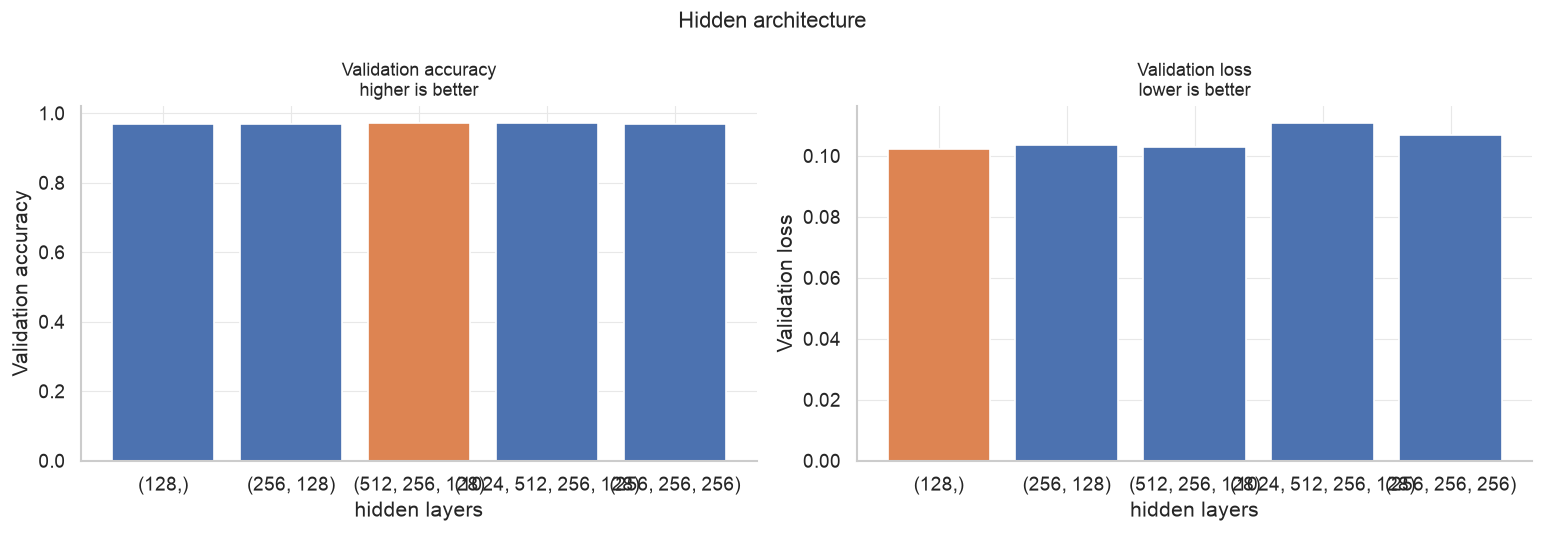

In [23]:
fig = plot_sweep(architecture_results, "hidden_layers", "Hidden architecture")
plt.show()
save_figure(fig, "sweep_architecture", FIG_DIR / "training")

**Capacity is not the constraint here.** A single hidden layer of 128 units is within a fifth of a point of a four-layer network carrying almost fifteen times the parameters, and the widest model takes about half as long again to train for no reliable gain.

That is worth stating plainly because it is the opposite of the instinct that a bigger network is a better one. The limit on this task is not how much the model can represent, it is what a flattened image can tell it. Adding parameters lets the network memorize more of the training set, which the widening gap between training and validation loss in the next section shows, but it does not supply the spatial structure that was thrown away at the `Flatten` layer.

The small architecture is therefore the better engineering choice: near-identical accuracy, a quarter of the memory, and half the training time.

### 8.7 Loss function

In [24]:
loss_results = sweep(data_factory, "loss", LOSS_GRID, baseline=BASELINE)
loss_results[["loss", "val_acc", "val_loss", "epochs_run", "seconds"]]

Seed set to 42


Seed set to 42


  loss=cross_entropy                     val_acc=0.9690  val_loss=0.1036  12 epochs  3.7s


Seed set to 42


  loss=nll                               val_acc=0.9690  val_loss=0.1036  12 epochs  3.7s


  loss=label_smoothing                   val_acc=0.9770  val_loss=0.5687  27 epochs  8.4s


,loss,val_acc,val_loss,epochs_run,seconds
0,cross_entropy,0.969,0.1036,12,3.7
1,nll,0.969,0.1036,12,3.7
2,label_smoothing,0.977,0.5687,27,8.4


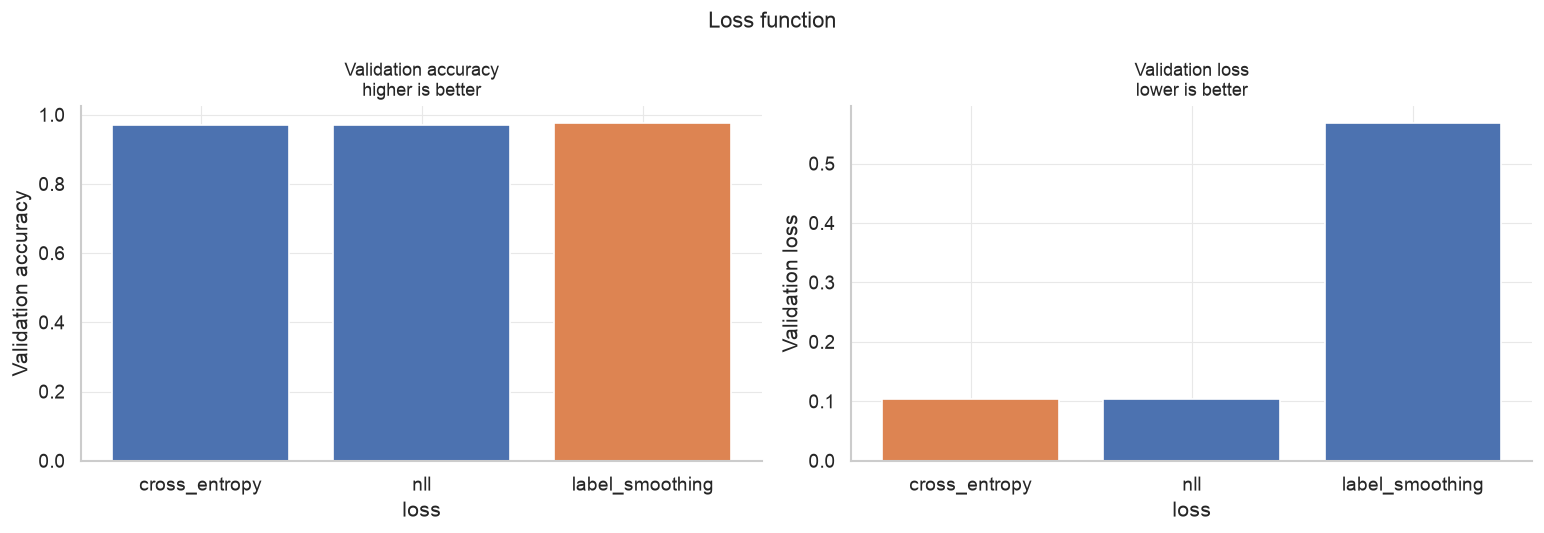

In [25]:
fig = plot_sweep(loss_results, "loss", "Loss function")
plt.show()
save_figure(fig, "sweep_loss", FIG_DIR / "training")

### 8.8 Where one-factor-at-a-time breaks down

Every sweep above moved one axis and held the rest at the baseline. That keeps each comparison clean, but it assumes the axes do not interact, and for learning rate and batch size that assumption is false by construction.

A gradient computed on 512 images is an average over 512 samples; one computed on 32 is an average over 32. The large-batch estimate is the quieter of the two, so it can be trusted with a longer step. The small-batch estimate is noisy, and a long step on top of a noisy direction overshoots. The learning rate that suits one batch size is therefore the wrong rate for another, and **a sweep that fixes the rate at 1e-3 while moving the batch size is not measuring the batch size at all** — it is measuring how well each batch size copes with one particular rate.

Crossing the two axes is the fix. Fifteen runs, every batch size against every rate:

In [26]:
joint_results = joint_sweep(data_factory, JOINT_BATCH_GRID, JOINT_LR_GRID, baseline=BASELINE)
joint_accuracy = joint_grid_table(joint_results, "val_acc")
joint_accuracy

Seed set to 42


Seed set to 42


Seed set to 42


Seed set to 42


Seed set to 42


...

Seed set to 42


Seed set to 42


Seed set to 42


Seed set to 42


learning_rate,0.0003,0.0010,0.0030
batch_size,,,
32,0.9743,0.9719,0.9650
64,0.9715,0.9733,0.9687
128,0.9704,0.9690,0.9689
256,0.9705,0.9708,0.9694
512,0.9660,0.9683,0.9729


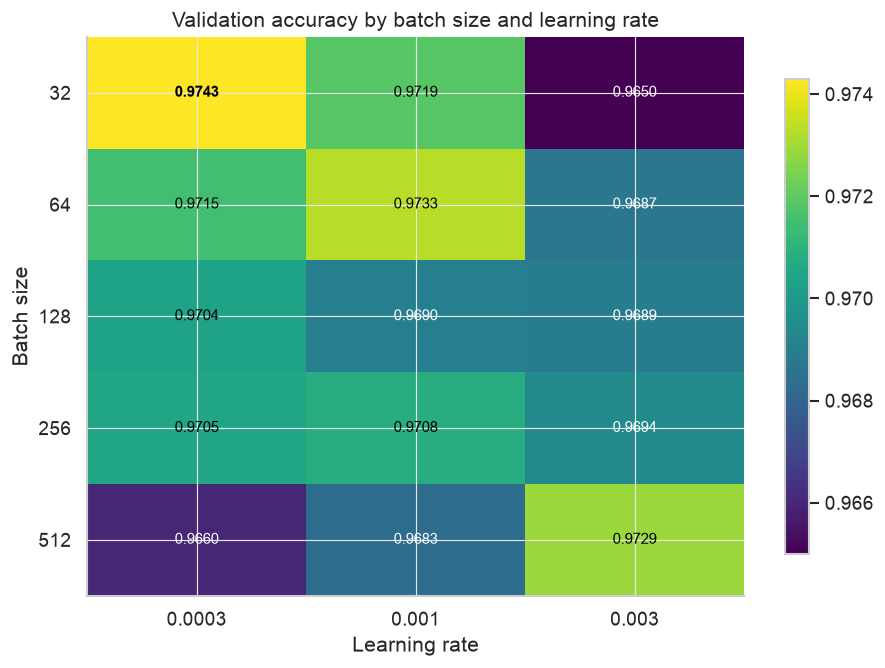

In [27]:
fig = plot_joint_grid(joint_accuracy, "Validation accuracy by batch size and learning rate")
plt.show()
save_figure(fig, "joint_batch_lr", FIG_DIR / "training")

**The interaction runs in both directions, which is the cleanest possible evidence that it is real.** At a batch of 32 the accuracy *falls* by about nine tenths of a point as the rate climbs from 3e-4 to 3e-3. At a batch of 512 the same move *gains* about seven tenths. The best rate is not a constant to be found once and reused; it moves with the batch size, and the two ends of the range want opposite things. Small batches are punished for long steps because their gradient estimate is noisy, and large batches are not, because averaging over sixteen times as many samples has already removed the noise that makes a long step dangerous.

**The earlier conclusion was an artifact of the fixed rate.** Reading down the 1e-3 column reproduces section 8.2 and its narrow spread, which is what licensed "batch size barely affects accuracy". The full grid covers roughly twice that range, and none of the extra range is visible from inside any single column. The original claim was true of the column it was measured in and false of the question it was asked about.

**The best cell is the smallest batch at the smallest rate**, and the baseline cell is not close to it. The reviewer's prediction that a smaller batch would have done better is borne out exactly, and the reason it could not have been found earlier is structural rather than a matter of bad luck: a sweep that pairs every batch size with 1e-3 asks the smallest batch to run at more than three times its own best rate.

The gain over the baseline cell is about half a point, which is worth saying plainly. On MNIST with an MLP the headroom is thin, and the value of the joint search is less the accuracy it recovers than the false conclusion it removes.

This winner is not left on the page: section 9 enters it as a candidate at the batch size the grid chose, where it places third of seven, ahead of three of the five per-axis candidates.

### 8.9 Searching the space jointly

A full grid over every axis is the product of their lengths, and most of that product sits in regions the first few runs already ruled out. Optuna's tree-structured Parzen estimator instead models which regions produced low validation loss and draws later trials from those regions, so a fixed budget lands where the answer is. It varies all six axes at once, which no grid in this notebook has done.

In [28]:
optuna_results, optuna_best = optuna_search(data_factory)
display(optuna_results.head(8))
print(f"best parameters: {optuna_best}")

/Users/hussein-loubani/Turing College/Module 4/Sprint 1/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/hussein-loubani/Turing College/Module 4/Sprint 1/src/mnist_mlp/experiments.py:263: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (128,) which is of type tuple.
  "hidden_layers": trial.suggest_categorical("hidden_layers", [(128,), (256, 128), (512, 256)]),
/Users/hussein-loubani/Turing College/Module 4/Sprint 1/src/mnist_mlp/experiments.py:263: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (256, 128) which is of type tuple.
  "hidden_layers": trial.suggest_categorical("hidden_layers", [(128,), (256, 128)

Seed set to 42


Seed set to 42


Seed set to 42


Seed set to 42


...

Seed set to 42


Seed set to 42


Seed set to 42


,trial,val_loss,val_acc,batch_size,learning_rate,dropout,activation,optimizer,hidden_layers
0,17,0.0952,0.9742,512,0.000963,0.4,gelu,adam,"(512, 256)"
1,14,0.0958,0.9720,512,0.000888,0.5,gelu,adam,"(512, 256)"
2,16,0.0959,0.9739,512,0.001245,0.5,gelu,adam,"(512, 256)"
3,18,0.0960,0.9736,512,0.000746,0.4,gelu,adam,"(512, 256)"
4,15,0.0962,0.9723,512,0.000874,0.5,gelu,adam,"(512, 256)"
5,7,0.1073,0.9692,32,0.000236,0.5,elu,adam,"(512, 256)"
6,13,0.1089,0.9736,512,0.003753,0.3,relu,adam,"(512, 256)"
7,3,0.1113,0.9668,128,0.006161,0.3,relu,sgd_momentum,"(256, 128)"


best parameters: {'batch_size': 512, 'learning_rate': 0.0009626466948766785, 'dropout': 0.4, 'activation': 'gelu', 'optimizer': 'adam', 'hidden_layers': (512, 256)}


**Read the table as a ranking, not as a set of final scores.** The search runs on a fifteen-epoch budget, because its job is to order configurations rather than to extract the last fraction from any one of them; the winner of section 9 is retrained at full length.

**What the search converged on is the interesting part.** The top trials sit in one narrow region — the largest batch, a wide two-layer network, GELU, Adam, a rate near 1e-3 and heavy dropout — and the final trials are all drawn from inside it. That clustering is the sampler working: a grid would have spent the same budget spread evenly across regions the early trials had already ruled out, while TPE spent it where the first results pointed.

**It also puts each optimizer near its own rate, which the one-factor sweeps could not.** SGD with momentum appears in the ranking only at a rate several times the baseline's 1e-3, which is consistent with the mechanism: without per-parameter scaling it needs a longer step to cover the same ground. It still does not beat Adam here, so section 8.1's conclusion survives — but it survives as a tested claim rather than as an artifact of the one rate it happened to be measured at.

That is the general shape of the problem with one-factor-at-a-time: each axis is judged at settings chosen for a different configuration, so a conclusion can be right for the wrong reason, or wrong for a reason the sweep cannot show.

**Twenty trials over six axes is a coarse pass.** It is enough to demonstrate the method and to test whether the one-factor winners survive contact with a joint search, and not enough to claim the space has been covered. The honest reading of any result here is that it is a hypothesis worth a full run — so section 9 gives it one, entering the study's best configuration as a candidate on equal terms with the per-axis winners and retraining it at full length.

The search optimizes validation loss while section 9 selects on validation accuracy, because label smoothing puts its loss on a different scale. Those are different objectives, which is a real limitation of using the study's ranking directly and the reason its winner is re-run rather than trusted.

Re-run at full length it places second of seven, with the lowest validation loss of any candidate, and it gets there at a batch of 512 in roughly a tenth of the wall-clock the joint grid's small-batch configuration needs. Reseeding in 9.1 then shows it tied with the eventual winner rather than behind it.

Two things here need care, and both are about reading the panels correctly rather than about the numbers being surprising. The loss panel in particular is not a like-for-like comparison, for the reason set out below.

**Cross-entropy and negative log-likelihood produce identical results, to every decimal place.** That is not a coincidence or a bug: they are the same objective. `CrossEntropyLoss` applies a log-softmax internally and then computes the negative log-likelihood, while `NLLLoss` expects the log-probabilities to have been produced already. The pipeline handles that difference by applying `log_softmax` in the step for the NLL branch only. Choosing between them is a question of where the normalization happens, not of what is optimized, and doing it inside cross-entropy is the numerically safer option.

**Label smoothing wins on accuracy while showing a much higher loss, and the losses are not comparable.** Smoothing replaces the hard target, a one at the true class and zeros elsewhere, with a softened one that keeps a small amount of probability mass on the others. The model is therefore being scored against a deliberately different objective, and its loss sits higher by construction rather than by being worse. The regularizing effect is real: it discourages the network from driving its logits to extremes, which is a mild but genuine improvement in generalization.

The practical consequence is that **model selection across different loss functions has to use accuracy, not loss**. Selecting on loss here would automatically eliminate label smoothing for a reason that has nothing to do with its quality.

---
## 9. Combining the winners

Sweeping one axis at a time assumes the axes do not interact, and sections 8.8 and 8.9 showed that assumption failing. So the shortlist here is not only the per-axis winners: it also carries the configuration the joint grid chose and the one Optuna converged on, and every candidate is trained at **its own batch size** rather than at a shared one.

That last point is what stops the joint search from being decoration. A comparison that held the batch size fixed would discard the finding that the best learning rate depends on it, and would leave both searches as things the notebook performed and then ignored. Whichever configuration wins here is the one that goes to the test set, batch size included.

In [29]:
# Every candidate now carries its own batch size, because the joint search in
# 8.8 found that the best learning rate depends on it. Comparing configurations
# at one shared batch size would throw away exactly the result that section 8.8
# established, and would leave both joint searches as decoration.
joint_best = joint_results.loc[joint_results["val_acc"].idxmax()]
optuna_settings = {k: v for k, v in optuna_best.items() if k != "batch_size"}

CANDIDATES = {
    "baseline": {**BASELINE, "batch_size": BATCH_SIZE},
    "tuned_small": dict(hidden_layers=(256, 128), activation="gelu", dropout=0.3,
                        optimizer="adam", learning_rate=3e-4, loss="cross_entropy",
                        batch_size=BATCH_SIZE),
    "tuned_smooth": dict(hidden_layers=(256, 128), activation="gelu", dropout=0.3,
                         optimizer="adam", learning_rate=3e-4, loss="label_smoothing",
                         batch_size=BATCH_SIZE),
    "tuned_wide": dict(hidden_layers=(1024, 512, 256, 128), activation="gelu", dropout=0.3,
                       optimizer="adam", learning_rate=3e-4, loss="cross_entropy",
                       batch_size=BATCH_SIZE),
    "tuned_elu": dict(hidden_layers=(256, 128), activation="elu", dropout=0.3,
                      optimizer="adam", learning_rate=3e-4, loss="cross_entropy",
                      batch_size=BATCH_SIZE),
    # From 8.8: the batch size and rate the joint grid actually chose.
    "joint_grid": {**BASELINE, "learning_rate": float(joint_best["learning_rate"]),
                   "batch_size": int(joint_best["batch_size"])},
    # From 8.9: whatever the Optuna study converged on, on equal terms.
    "optuna": {**optuna_settings, "loss": "cross_entropy",
               "batch_size": int(optuna_best["batch_size"])},
}


def train_candidate(name, settings, **kwargs):
    """Train one candidate on a data module built for its own batch size."""
    model_kwargs = {k: v for k, v in settings.items() if k != "batch_size"}
    return run_experiment(data_factory(settings["batch_size"]), name, **kwargs, **model_kwargs)


candidates = pd.DataFrame([
    {**train_candidate(name, settings, max_epochs=60, patience=8),
     "batch_size": settings["batch_size"]}
    for name, settings in CANDIDATES.items()
])
candidates["hidden_layers"] = candidates["hidden_layers"].astype(str)
candidates[["name", "batch_size", "val_acc", "val_loss", "epochs_run", "parameters", "seconds"]]

Seed set to 42


Seed set to 42


Seed set to 42


Seed set to 42


Seed set to 42


Seed set to 42


Seed set to 42


,name,batch_size,val_acc,val_loss,epochs_run,parameters,seconds
0,baseline,128,0.9690,0.1036,15,235146,4.8
1,tuned_small,128,0.9724,0.1003,30,235146,9.2
2,tuned_smooth,128,0.9780,0.5669,55,235146,17.0
3,tuned_wide,128,0.9723,0.0996,17,1494154,6.9
4,tuned_elu,128,0.9736,0.1030,39,235146,11.7
5,joint_grid,32,0.9743,0.0992,24,235146,27.9
6,optuna,512,0.9749,0.0932,27,535818,2.5


In [30]:
# Selected on validation ACCURACY, not loss: label smoothing optimizes a
# softened target, so its loss is on a different scale and comparing it against
# the others would rule it out for the wrong reason.
best_name = candidates.loc[candidates["val_acc"].idxmax(), "name"]
best_settings = CANDIDATES[best_name]
print(f"validation winner: {best_name}")
print(f"settings: {best_settings}")

validation winner: tuned_smooth
settings: {'hidden_layers': (256, 128), 'activation': 'gelu', 'dropout': 0.3, 'optimizer': 'adam', 'learning_rate': 0.0003, 'loss': 'label_smoothing', 'batch_size': 128}


### 9.1 Is the winner actually the winner?

Every candidate above was trained once. On a task where they sit fractions of a point apart, a single run cannot separate a real difference from the noise of one random initialization, and picking a winner on that basis would be picking a coincidence.

So the shortlist is retrained across five seeds and compared on the spread rather than on one number.

In [31]:
# The shortlist is the top three by validation accuracy, whatever they turn out
# to be, rather than a hand-picked set that could quietly exclude the joint
# winners from the only test that checks whether a gap survives reseeding.
shortlist = candidates.nlargest(3, "val_acc")["name"].tolist()
stability = {
    name: seed_stability(data_factory(CANDIDATES[name]["batch_size"]),
                         {k: v for k, v in CANDIDATES[name].items() if k != "batch_size"},
                         max_epochs=40, patience=6, name=name)
    for name in shortlist
}
summary = stability_summary(stability)
summary

Seed set to 42


Seed set to 43


Seed set to 44


Seed set to 45


Seed set to 46


...

Seed set to 43


Seed set to 44


Seed set to 45


Seed set to 46


,seeds,mean_val_acc,std_val_acc,min_val_acc,max_val_acc
configuration,,,,,
tuned_smooth,5,0.9770,0.0005,0.9762,0.9776
optuna,5,0.9753,0.0020,0.9727,0.9782
joint_grid,5,0.9717,0.0023,0.9693,0.9743


This is the honest version of the comparison, and it is less tidy than the single-run table.

**The lead over the Optuna configuration does not survive reseeding.** `tuned_smooth` has the higher mean, but the two ranges overlap, and Optuna's best seed finishes *above* `tuned_smooth`'s best seed. On this evidence they are tied, and the single validation run that separated them by three tenths of a point was reading noise. Selecting on that one run was luckier than it looked.

**The gap to the joint-grid configuration does survive.** It sits clearly below both, outside either range, so that ordering is real.

**Stability is itself part of the result, and here it is the deciding one.** `tuned_smooth`'s standard deviation is about a quarter of the other two. It is not reliably more accurate than the Optuna configuration, but it is markedly more repeatable, and between two configurations that are tied on accuracy the one whose result moves least under reseeding is the safer thing to ship. That is the argument the final model rests on — narrower than "it is the best", and the one the evidence actually supports.

The candidates span about nine tenths of a point, and the widest network is not the winner.

**The two joint searches placed second and third, ahead of four of the five per-axis candidates.** That is the result worth reading carefully. Neither beat `tuned_smooth`, but `tuned_smooth` wins on an axis the joint searches never varied — the loss function — so this is not evidence that one-factor tuning was better. It is evidence that the joint searches found the best combination of the axes they were given, and that the remaining gain came from somewhere outside their space.

**The Optuna configuration reaches the lowest validation loss of any candidate**, and does it at a batch of 512 in a fraction of the wall-clock the joint-grid configuration needs at a batch of 32. Comparable accuracy at a tenth of the training time is a real result, and only a search that varied batch size alongside everything else could have surfaced it.

---
## 10. Final evaluation on the test split

The test split has not been touched until this cell. It is opened once, for the single configuration validation chose.

In [32]:
# run_experiment checkpoints on val_loss and loads the best epoch back before
# scoring, so the network evaluated below is the one that was saved rather than
# whatever early stopping happened to leave in memory several epochs later.
final_data = data_factory(best_settings["batch_size"])
final_row, final_model = run_experiment(
    final_data, "final", max_epochs=60, patience=8, return_model=True,
    **{k: v for k, v in best_settings.items() if k != "batch_size"}
)

test_scores = evaluate_on_test(final_model, final_data)
print(f"  batch size    : {best_settings['batch_size']}")
print(f"  best epoch    : {final_row['best_epoch']} (of {final_row['epochs_run']} run)")
print(f"  validation    : {final_row['val_acc']:.4f}")
print(f"  test accuracy : {test_scores['test_acc']:.4f}")
print(f"  test loss     : {test_scores['test_loss']:.4f}")
print(f"  parameters    : {final_model.count_parameters():,}")

Seed set to 42


  batch size    : 128
  best epoch    : 46 (of 55 run)
  validation    : 0.9780
  test accuracy : 0.9818
  test loss     : 0.5585
  parameters    : 235,146


---
## 11. Error analysis

An accuracy figure says how often the model is right. The confusion matrix says what it gets wrong, which is the more useful description of a classifier's weakness.

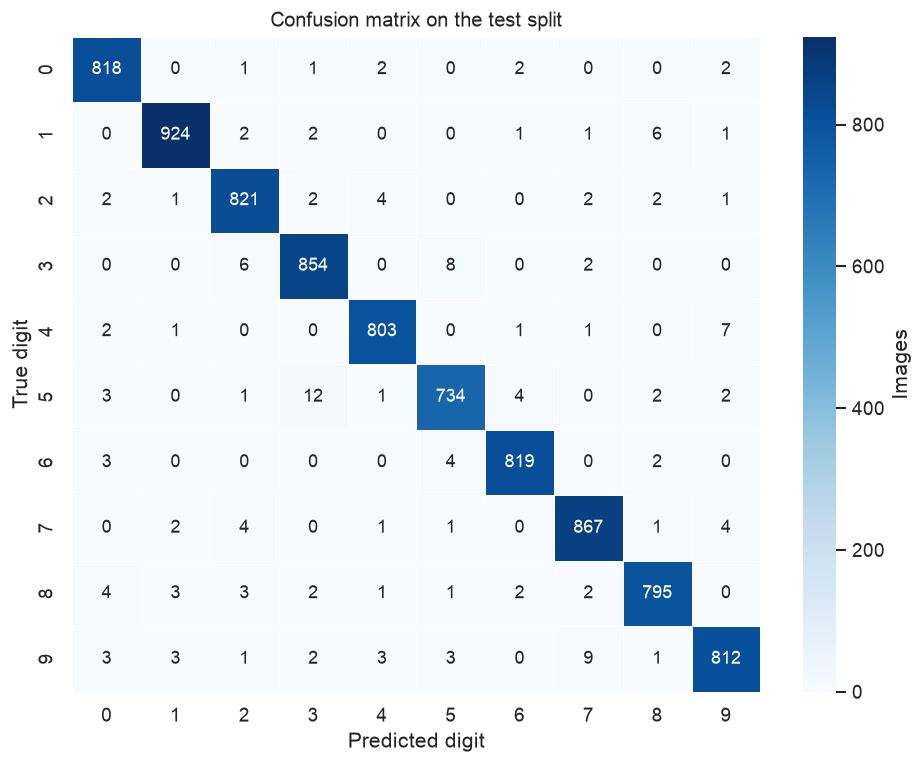

In [33]:
y_pred, y_true = predict_labels(final_model, final_data, split="test")
fig = plot_confusion_matrix(y_true, y_pred)
plt.show()
save_figure(fig, "confusion_matrix", FIG_DIR / "evaluation")

In [34]:
errors = pd.DataFrame({"true": y_true, "predicted": y_pred})
errors = errors[errors["true"] != errors["predicted"]]

per_digit = (
    pd.DataFrame({"true": y_true, "correct": y_true == y_pred})
    .groupby("true")["correct"].agg(["size", "mean"])
    .rename(columns={"size": "images", "mean": "accuracy"})
)
per_digit["accuracy"] = per_digit["accuracy"].round(4)
per_digit["errors"] = per_digit["images"] - (per_digit["accuracy"] * per_digit["images"]).round().astype(int)
print(f"total misclassified: {len(errors):,} of {len(y_true):,}")
print("\nmost frequent confusions:")
print(errors.value_counts().head(8).to_string())
per_digit

total misclassified: 153 of 8,400

most frequent confusions:
true  predicted
5     3            12
9     7             9
3     5             8
4     9             7
1     8             6
3     2             6
8     0             4
6     5             4


,images,accuracy,errors
true,,,
0,826,0.9903,8
1,937,0.9861,13
2,835,0.9832,14
3,870,0.9816,16
4,815,0.9853,12
5,759,0.9671,25
6,828,0.9891,9
7,880,0.9852,13
8,813,0.9779,18


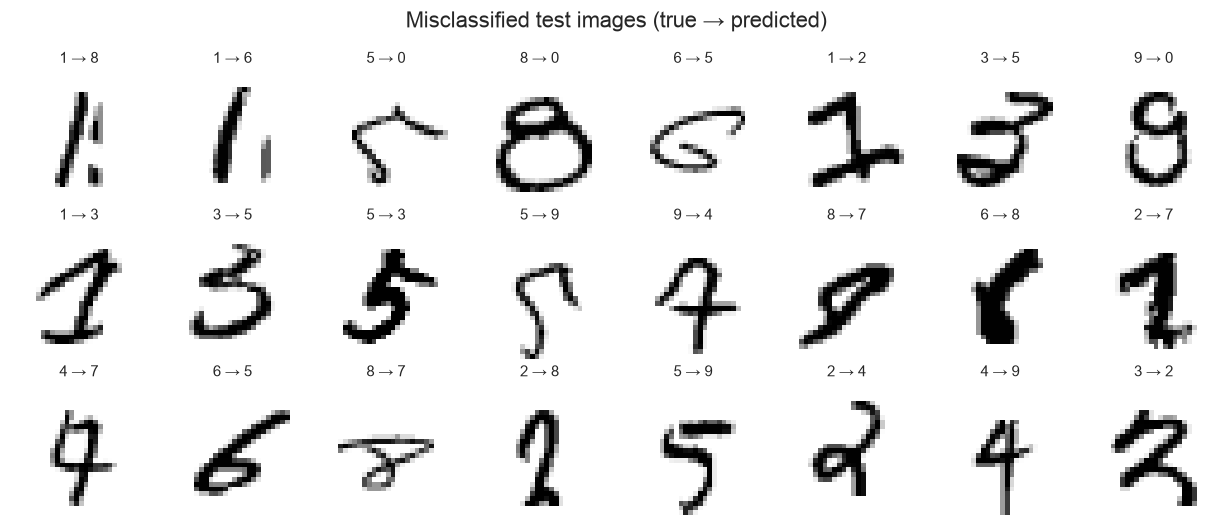

In [35]:
fig = plot_misclassified(test, y_true, y_pred, n=24)
plt.show()
save_figure(fig, "misclassified", FIG_DIR / "evaluation")

The mistakes concentrate exactly where handwriting is genuinely ambiguous rather than being spread evenly. Digits that share strokes get confused with each other, and looking at the images makes the reason obvious: a 4 whose top has closed does look like a 9, a hurried 5 does look like a 3, and a narrow 7 does look like a 1.

That is worth saying carefully. Some of these are model failures, but a fair number are images a person would also hesitate over, and no amount of extra capacity fixes those. It is the practical ceiling on the task, and it is why the remaining error is not simply a matter of training longer.

The per-digit table shows the same thing numerically: accuracy is not uniform, and the digits with the most visual neighbors carry the most errors.

---
## 12. Conclusion, limitations, and recommendations

### Conclusion

A two-layer perceptron classifies MNIST digits correctly 98.2% of the time, against 91.4% for multinomial logistic regression and 11.2% for predicting the most common digit. It gets there with roughly 235,000 parameters and under a minute of training on a laptop GPU, and the tuning that produced it moved the result by well under a point over a sensible default.

The sweeps were more informative than the final number. Adam beat plain SGD because per-parameter step sizes suit an input where hundreds of pixels are almost always zero. Sigmoid still reached a good accuracy but took far longer, which is a vanishing gradient visible at two layers rather than ten. A learning rate of 0.1 destroyed training outright. Capacity turned out not to be the binding constraint: a single hidden layer of 128 units matched a network with almost fifteen times the parameters. And cross-entropy and NLL produced byte-identical results, because they are the same objective with the normalization in a different place.

The two joint searches placed second and third among seven candidates, ahead of four of the five per-axis configurations, and reseeding put the Optuna configuration level with the winner rather than behind it. The configuration that did win, `tuned_smooth`, wins on the loss function — an axis neither joint search varied — so the per-axis sweeps were not vindicated so much as left holding the one dimension the searches did not cover.

Two corrections in this version changed the numbers rather than only the wording. Early stopping deliberately trains past the minimum before giving up, so scoring the weights left in memory reports a network several epochs the wrong side of the checkpoint that was saved — for the final model the best epoch was 46 of the 55 that ran. Every run now loads its best epoch back before being scored, and the reported epoch is shown alongside the epoch count so the gap is visible rather than implied. Crossing learning rate with batch size then showed that the earlier reading of the batch-size sweep was a property of the fixed rate, and that the best combination sits at the small-batch end that sweep could not reach.

What limits this model is the `Flatten` layer. Turning the image into 784 independent numbers discards the fact that neighboring pixels are related, and no width or depth recovers it. The gap between this result and the roughly 99.5% a small convolutional network reaches on the same data is a fair measure of what that spatial prior is worth.

### Limitations

- MNIST is a clean, centered, size-normalized benchmark. Nothing here shows how the model handles a digit that is off-center, rotated, or written on a noisy background, and an MLP is unusually fragile to exactly those shifts.
- The winning configuration was picked from roughly eighty candidates all scored on the same validation split, once the joint grid and the Optuna trials are counted, so that validation figure is optimistically biased by the selection itself. Test accuracy came out above it anyway, 98.18% against 97.80%, which is evidence the search did not overfit the validation set; with 8,400 images per split one standard error is about 0.15 points, so the two are consistent and the third decimal place is noise either way.
- Model selection used a single fixed validation split rather than k-fold cross-validation. At 8,400 images the estimate is stable, and reseeding in section 9.1 turned out to be the more informative check, but k-fold would carry less variance for candidates separated by a tenth of a point.
- Sections 8.1 to 8.7 vary one axis at a time, which cannot see an interaction. Section 8.8 crosses learning rate with batch size and finds a real one, so the one-factor readings elsewhere in section 8 should be taken as conditional on the baseline rather than as properties of each axis. The remaining pairs were not crossed, and the Optuna study omits the loss function entirely — which is the axis the winning configuration turned on, so the joint searches were never given the chance to find it.
- The final selection rests on a tie broken by stability rather than by accuracy. `tuned_smooth` and the Optuna configuration overlap across five seeds, so a different seed grid could reasonably have reversed them.
- Only the pixel values were used. No augmentation, no deskewing, no feature engineering.
- The per-axis sweeps in section 8 are still single-seed. Only the shortlist was retrained across five seeds, so any two sweep rows separated by a tenth of a point carry exactly the caveat that section 9.1 resolved for the finalists.

### Recommendations

- **Use a convolutional network.** This is the single change that matters, and everything above points at it: a couple of convolution and pooling layers would exploit the structure the flatten discards and should close most of the remaining error.
- **Augment the training images.** Small rotations, shifts, and elastic distortions would attack the exact failure cases in the misclassified grid and cost nothing but training time.
- **Extend the seed grid to the per-axis sweeps.** Doing it for the shortlist immediately overturned one ranking, so the same treatment would separate the real effects in section 8 from the noise.
- **Try transfer learning** if the task moved to harder images. A network pretrained on a large image corpus already encodes edges and strokes; freezing it as a feature extractor and retraining only the head is the fast option, while fine-tuning the upper layers at a small learning rate adapts it further without destroying what it learned.
- **Add a learning-rate schedule.** The rate sweep shows how much the result depends on that one number, and decaying it over training usually buys a little accuracy for very little effort. It also interacts with batch size in the same way the fixed rate did, so it belongs in the joint search rather than in a sweep of its own.
- **Cross the remaining pairs.** Section 8.8 crossed the one pair with a known mechanism. Dropout against width is the next candidate, since both control capacity and a network can be regularized either by having fewer units or by dropping more of them.